In [3]:
import jax
import jax.numpy as jnp
from jax import value_and_grad, jit
import numpy as np
import matplotlib.pyplot as plt

# Configuración para que las gráficas usen un estilo científico limpio
plt.style.use('default')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'lines.markersize': 6
})

# ==========================================
# CARGA DE DATOS
# ==========================================
# Leemos el archivo específico con el ID del enunciado
# Asumimos que los archivos internos se llaman X, y, t según la estructura de npz
datos = np.load('datos_5303.npz')

# Convertimos los datos a arrays de JAX para poder usarlos en la red
X = jnp.array(datos['X']) # Matriz de señales (36, 256)
y = jnp.array(datos['y']) # Etiquetas de los regímenes (36,)
t = jnp.array(datos['t']) # Vector de tiempo (256,)

print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")
print(f"Forma de t: {t.shape}")

Forma de X: (36, 256)
Forma de y: (36,)
Forma de t: (256,)


# 1. Capa Fourier

Construiremos la matriz $W_1$ utilizando senos y cosenos. Verificaremos que actúa como una transformada de Fourier proyectando una señal sobre esta matriz y comparándola con np.fft. Finalmente, calcularemos la energía media del dataset.

Forma de la matriz W1 (Fourier): (30, 256)


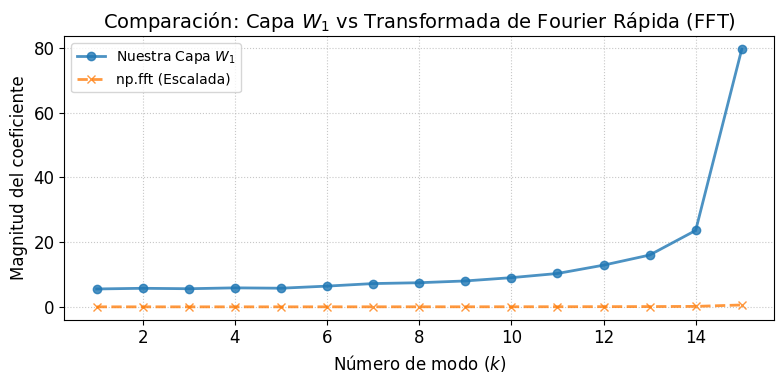

Energía media del dataset: 0.730


In [4]:

def crear_w1_fourier(K, t):
    """
    Construye la matriz W1 con filas de senos y cosenos.
    K: número de frecuencias (15 según el enunciado).
    t: vector de tiempo.
    """
    filas = []
    # Iteramos desde k=1 hasta K para crear las frecuencias
    for k in range(1, K + 1):
        # Agregamos la fila del seno y luego la del coseno
        filas.append(jnp.sin(2 * jnp.pi * k * t))
        filas.append(jnp.cos(2 * jnp.pi * k * t))

    # jnp.vstack apila todas las filas en una sola matriz de forma (2K, 256)
    return jnp.vstack(filas)

# Definimos K=15 como pide el enunciado
K = 15
W1_fourier = crear_w1_fourier(K, t)
print(f"Forma de la matriz W1 (Fourier): {W1_fourier.shape}")

# ------------------------------------------
# Evidencia: Comparación con np.fft
# ------------------------------------------
# Tomamos la primera señal para la prueba
senal_prueba = X[0]

# 1. Proyección manual usando nuestra matriz W1
# Al multiplicar W1 por la señal, obtenemos los coeficientes de Fourier
coeficientes_W1 = jnp.dot(W1_fourier, senal_prueba)
# Calculamos la magnitud combinando cada par de seno/coseno (a^2 + b^2)
magnitud_W1 = jnp.sqrt(coeficientes_W1[0::2]**2 + coeficientes_W1[1::2]**2)

# 2. Transformada usando numpy (np.fft)
fft_numpy = np.fft.fft(senal_prueba)
# Tomamos las frecuencias positivas, ignorando la frecuencia cero (continua)
# y limitamos hasta K para poder comparar manzanas con manzanas.
magnitud_fft = np.abs(fft_numpy)[1:K+1]

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, K+1), magnitud_W1, marker='o', label='Nuestra Capa $W_1$', alpha=0.8)
# Escalamos la FFT de numpy por un factor normalizador (2/N) para que las amplitudes coincidan
ax.plot(range(1, K+1), magnitud_fft * (2 / len(t)), marker='x', linestyle='--', label='np.fft (Escalada)', alpha=0.8)

ax.set_title("Comparación: Capa $W_1$ vs Transformada de Fourier Rápida (FFT)")
ax.set_xlabel(r"Número de modo ($k$)")
ax.set_ylabel(r"Magnitud del coeficiente")
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------
# Reporte de energía media
# ------------------------------------------
# Calculamos la energía media del dataset como (X**2).mean()
energia_media = (X**2).mean()
print(f"Energía media del dataset: {energia_media:.3f}")

# 2. Entrenamiento y Reconstrucción

En esta sección definiremos la arquitectura de la red: $\hat{x} = W_2\,\tanh(W_1 x)$. Implementaremos el ciclo de entrenamiento minimizando el Error Cuadrático Medio ($\mathcal{L}$) y usaremos el Descenso del Gradiente (SGD) estándar con la tasa de aprendizaje sugerida de $\eta = 0.05$.

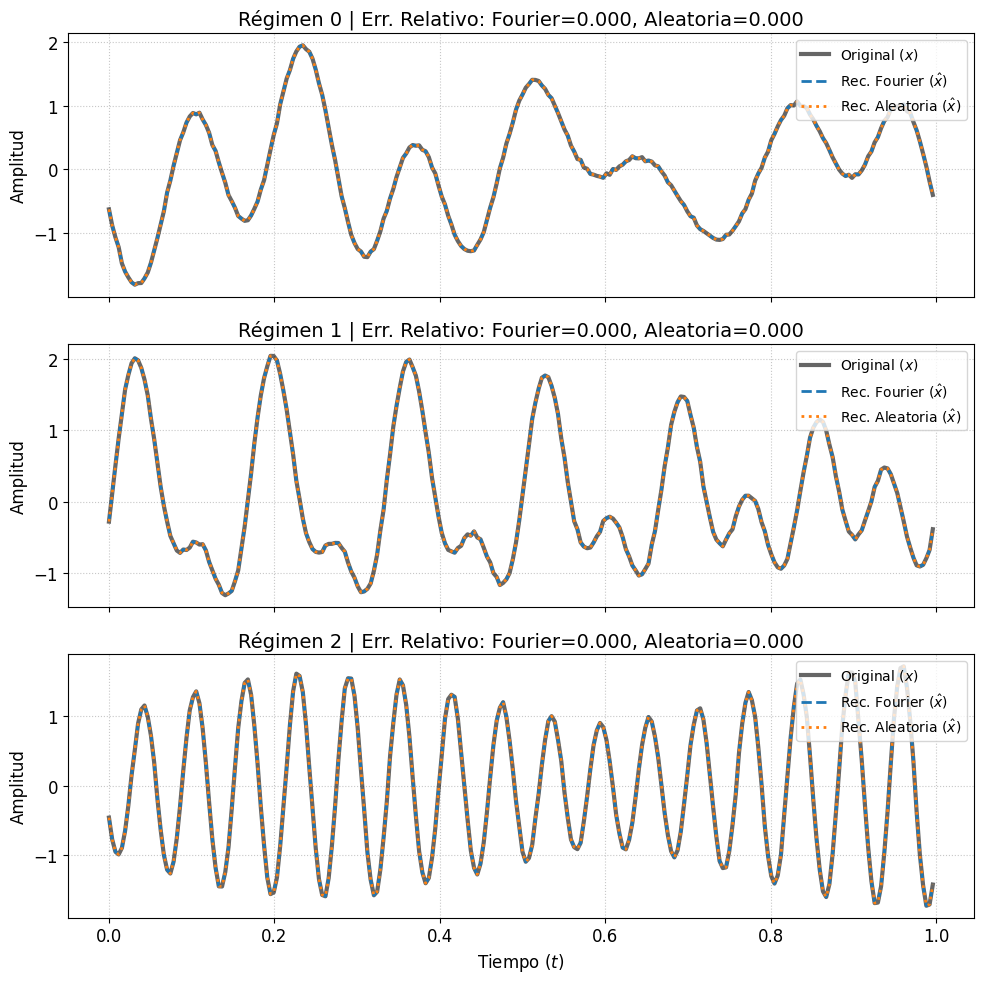

In [5]:
# 1. Función para inicializar los pesos de la red
def inicializar_pesos(semilla, inicializacion="fourier", K=15):
    llave = jax.random.PRNGKey(semilla)
    llave_w1, llave_w2 = jax.random.split(llave)

    # Inicialización de W1
    if inicializacion == "fourier":
        W1 = crear_w1_fourier(K, t)
    elif inicializacion == "aleatoria":
        # Pesos aleatorios con distribución normal escalada
        W1 = jax.random.normal(llave_w1, (2 * K, len(t))) * 0.1
    else:
        raise ValueError("Inicialización no válida")

    # Inicialización de W2 (siempre aleatoria o ceros, aquí usamos normal pequeña)
    W2 = jax.random.normal(llave_w2, (len(t), 2 * K)) * 0.1

    return {"W1": W1, "W2": W2}

# 2. Arquitectura de la red neuronal (propagación hacia adelante)
def predecir(pesos, x):
    # Capa oculta: W1 * x, luego función de activación tangente hiperbólica
    capa_oculta = jnp.tanh(jnp.dot(pesos["W1"], x))
    # Capa de salida: W2 * capa_oculta
    x_reconstruida = jnp.dot(pesos["W2"], capa_oculta)
    return x_reconstruida

# 3. Función de pérdida (MSE - Mean Squared Error)
def calcular_perdida(pesos, x):
    x_hat = predecir(pesos, x)
    # L = (1/N) * ||x_hat - x||^2
    return jnp.mean((x_hat - x)**2)

# JIT compila la función (pérdida + gradiente) para que corra ultra rápido en la GPU/CPU
@jit
def paso_entrenamiento(pesos, x, tasa_aprendizaje):
    # value_and_grad devuelve el valor de la pérdida y las derivadas respecto a los pesos
    perdida, gradientes = value_and_grad(calcular_perdida)(pesos, x)

    # Actualizamos los pesos usando descenso del gradiente: W = W - eta * dW
    pesos_actualizados = {
        "W1": pesos["W1"] - tasa_aprendizaje * gradientes["W1"],
        "W2": pesos["W2"] - tasa_aprendizaje * gradientes["W2"]
    }
    return pesos_actualizados, perdida

# 4. Función principal de entrenamiento
def entrenar_red(x, inicializacion, iteraciones=2000, tasa_aprendizaje=0.05):
    pesos = inicializar_pesos(semilla=42, inicializacion=inicializacion)
    historial_perdida = []

    for i in range(iteraciones):
        pesos, perdida = paso_entrenamiento(pesos, x, tasa_aprendizaje)
        historial_perdida.append(perdida)

    x_hat = predecir(pesos, x)

    # Error relativo de reconstrucción: |x - x_hat| / |x|
    # Usamos la norma L2 (jnp.linalg.norm) para los vectores
    error_relativo = jnp.linalg.norm(x - x_hat) / jnp.linalg.norm(x)

    return pesos, x_hat, historial_perdida, error_relativo

# ------------------------------------------
# Ejecución para una señal de cada régimen
# ------------------------------------------
# Encontramos el índice de la primera señal de cada régimen (0, 1, y 2)
indices_regimenes = [jnp.where(y == r)[0][0] for r in [0, 1, 2]]

resultados = {}

for reg, idx in enumerate(indices_regimenes):
    senal_x = X[idx]

    # Entrenamos con Fourier
    p_f, x_hat_f, loss_f, err_f = entrenar_red(senal_x, "fourier")
    # Entrenamos Aleatorio
    p_a, x_hat_a, loss_a, err_a = entrenar_red(senal_x, "aleatoria")

    resultados[reg] = {
        "x": senal_x,
        "x_hat_fourier": x_hat_f, "loss_fourier": loss_f, "err_fourier": err_f,
        "x_hat_aleatoria": x_hat_a, "loss_aleatoria": loss_a, "err_aleatoria": err_a
    }

# ------------------------------------------
# Gráficas y Reporte de Errores
# ------------------------------------------
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

for reg in range(3):
    ax = axs[reg]
    res = resultados[reg]

    ax.plot(t, res["x"], label=r'Original ($x$)', color='black', alpha=0.6, linewidth=3)
    ax.plot(t, res["x_hat_fourier"], label=r'Rec. Fourier ($\hat{x}$)', linestyle='--')
    ax.plot(t, res["x_hat_aleatoria"], label=r'Rec. Aleatoria ($\hat{x}$)', linestyle=':')

    titulo = f"Régimen {reg} | Err. Relativo: Fourier={res['err_fourier']:.3f}, Aleatoria={res['err_aleatoria']:.3f}"
    ax.set_title(titulo)
    ax.set_ylabel("Amplitud")
    ax.legend(loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.7)

axs[-1].set_xlabel("Tiempo ($t$)")
plt.tight_layout()
plt.show()

# 3. Comparación de Inicializaciones

Analizaremos la velocidad de convergencia. El enunciado pide prestar especial atención al Régimen 2. Como el parámetro $\mu > 0$ en el régimen 2 empuja las frecuencias hacia arriba, la base de Fourier inicial ($K=15$) podría quedarse "corta" si las frecuencias reales de la señal son mayores, lo que obliga a la red a ajustar agresivamente sus pesos durante el entrenamiento.

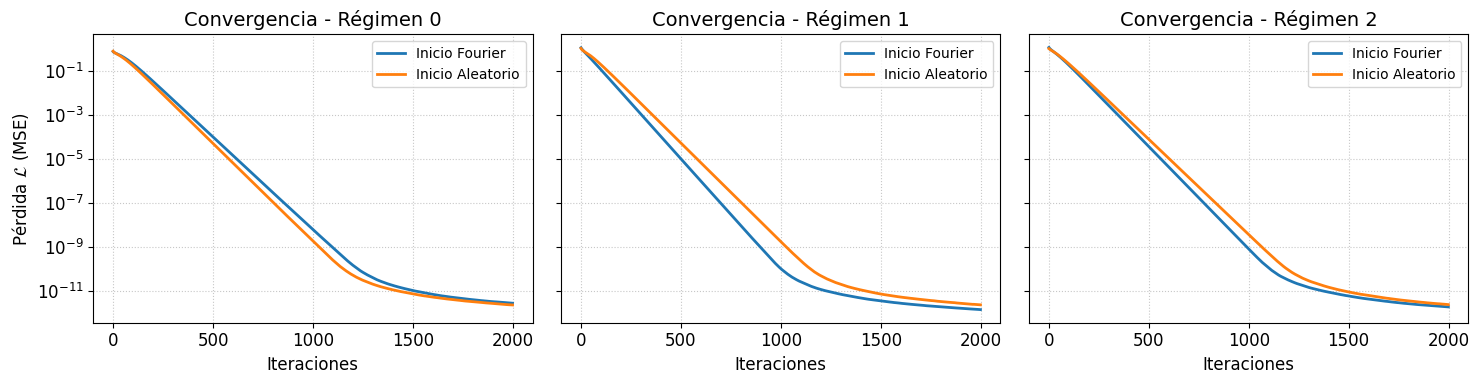

--- Iteraciones para alcanzar Error Relativo <= 0.1 ---
Régimen 0: Fourier necesitó 280 iter., Aleatoria necesitó 258 iter.
Régimen 1: Fourier necesitó 212 iter., Aleatoria necesitó 255 iter.
Régimen 2: Fourier necesitó 240 iter., Aleatoria necesitó 259 iter.


In [6]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for reg in range(3):
    res = resultados[reg]
    ax = axs[reg]

    # Graficamos la historia de la pérdida (MSE)
    ax.plot(res["loss_fourier"], label='Inicio Fourier', color='C0')
    ax.plot(res["loss_aleatoria"], label='Inicio Aleatorio', color='C1')

    # Buscamos en qué iteración el error relativo baja de 0.1
    # Nota: la pérdida es MSE, pero calcularemos el error relativo iterativamente para ser estrictos
    ax.set_title(f"Convergencia - Régimen {reg}")
    ax.set_xlabel("Iteraciones")
    if reg == 0:
        ax.set_ylabel(r"Pérdida $\mathcal{L}$ (MSE)")
    ax.set_yscale('log') # Escala logarítmica para ver mejor la caída del error
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------
# Medición de iteraciones para Error Relativo <= 0.1
# ------------------------------------------
def iteraciones_para_umbral(x, inicializacion, umbral=0.1, iteraciones=2000, lr=0.05):
    pesos = inicializar_pesos(semilla=42, inicializacion=inicializacion)
    norma_x = jnp.linalg.norm(x)

    for i in range(iteraciones):
        pesos, _ = paso_entrenamiento(pesos, x, lr)
        x_hat = predecir(pesos, x)
        err_rel = jnp.linalg.norm(x - x_hat) / norma_x

        if err_rel <= umbral:
            return i + 1 # Retornamos el número de la iteración

    return -1 # Si no llega al umbral en las iteraciones dadas

print("--- Iteraciones para alcanzar Error Relativo <= 0.1 ---")
for reg, idx in enumerate(indices_regimenes):
    senal = X[idx]
    iter_f = iteraciones_para_umbral(senal, "fourier")
    iter_a = iteraciones_para_umbral(senal, "aleatoria")

    it_f_str = str(iter_f) if iter_f != -1 else ">2000"
    it_a_str = str(iter_a) if iter_a != -1 else ">2000"
    print(f"Régimen {reg}: Fourier necesitó {it_f_str} iter., Aleatoria necesitó {it_a_str} iter.")

# 4. Compresión

Vamos a evaluar cuántos coeficientes de la base original de Fourier bastan para conservar el 95% de la energía de la señal. Al ordenar los coeficientes de mayor a menor magnitud, podemos acumular su energía hasta sobrepasar el umbral.

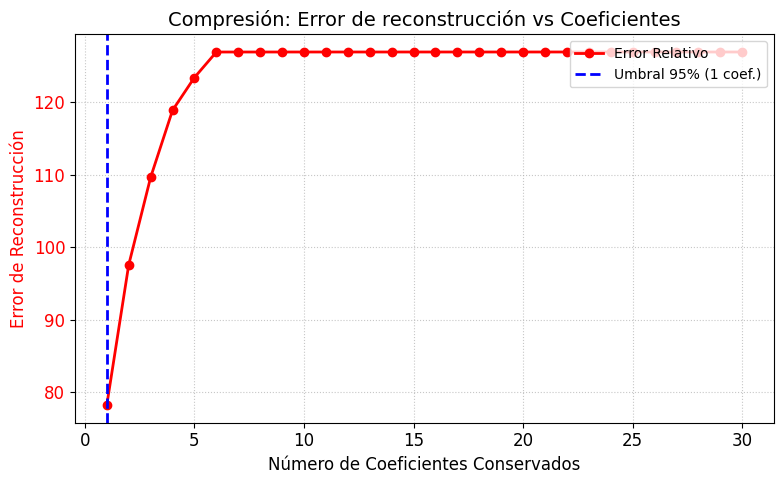

Para conservar el 95.0% de la energía se necesitan 1 coeficientes.


In [7]:
# Tomamos una señal de prueba (por ejemplo, del régimen 0)
senal_compresion = X[indices_regimenes[0]]

# Proyectamos la señal en la base de Fourier (sin entrenar, pura matemática)
coeficientes = jnp.dot(W1_fourier, senal_compresion)

# Calculamos la energía de cada coeficiente (magnitud al cuadrado)
# Dado que tenemos seno y coseno separados, evaluaremos la energía total aportada
energia_coeficientes = coeficientes**2

# Ordenamos las energías de mayor a menor (descendente)
indices_ordenados = jnp.argsort(energia_coeficientes)[::-1]
energia_ordenada = energia_coeficientes[indices_ordenados]

# Calculamos la energía acumulada
energia_total_senal = jnp.sum(senal_compresion**2)
energia_acumulada = jnp.cumsum(energia_ordenada)
porcentaje_acumulado = energia_acumulada / energia_total_senal

# Buscamos cuántos coeficientes necesitamos para llegar al 95% (0.95)
umbral_energia = 0.95
coeficientes_necesarios = jnp.argmax(porcentaje_acumulado >= umbral_energia) + 1

# ------------------------------------------
# Gráfica de compresión
# ------------------------------------------
# Evaluamos el error de reconstrucción usando solo 'n' coeficientes
errores_reconstruccion = []
num_coeficientes_lista = range(1, len(coeficientes) + 1)

for n in num_coeficientes_lista:
    # Creamos una máscara que conserva solo los 'n' coeficientes más grandes
    coeficientes_filtrados = jnp.zeros_like(coeficientes)
    indices_a_conservar = indices_ordenados[:n]
    # Reemplazamos usando `.at[].set()` que es la forma segura de asignar en JAX
    coeficientes_filtrados = coeficientes_filtrados.at[indices_a_conservar].set(coeficientes[indices_a_conservar])

    # Reconstruimos usando la pseudoinversa (o transpuesta, al ser ortogonales)
    # W1.T proyecta de los coeficientes de vuelta al tiempo
    senal_reconstruida = jnp.dot(W1_fourier.T, coeficientes_filtrados)

    # Calculamos error relativo
    error = jnp.linalg.norm(senal_compresion - senal_reconstruida) / jnp.linalg.norm(senal_compresion)
    errores_reconstruccion.append(error)

fig, ax1 = plt.subplots(figsize=(8, 5))

# Eje principal: Error de reconstrucción
ax1.plot(num_coeficientes_lista, errores_reconstruccion, color='red', marker='o', label='Error Relativo')
ax1.set_xlabel('Número de Coeficientes Conservados')
ax1.set_ylabel('Error de Reconstrucción', color='red')
ax1.tick_params(axis='y', labelcolor='red')

# Línea vertical indicando el umbral
ax1.axvline(x=coeficientes_necesarios, color='blue', linestyle='--', label=f'Umbral 95% ({coeficientes_necesarios} coef.)')
ax1.grid(True, linestyle=':', alpha=0.7)

# Título y leyenda
plt.title('Compresión: Error de reconstrucción vs Coeficientes')
ax1.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"Para conservar el {umbral_energia*100}% de la energía se necesitan {coeficientes_necesarios} coeficientes.")